In [1]:
import tensorflow as tf
from tensorflow import keras

import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics

# discontinued import tensorflow_addons as tfa
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import load_model

In [2]:
base_dir = r"C:\Users\Aryan\Downloads\Dataset-train+val+test"
print('Base directory --> ', os.listdir(base_dir))

Base directory -->  ['test', 'train', 'val']


In [3]:
# NOT EXCHANGED

train_dir = os.path.join(base_dir + "/train/")
print("Train Directory --> ", os.listdir(train_dir))

validation_dir = os.path.join(base_dir + "/val/")
print("Validation Directory --> ", os.listdir(validation_dir))

test_dir = os.path.join(base_dir + "/test/")
print("Test Directory --> ", os.listdir(test_dir))

Train Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Validation Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Test Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [4]:
cnv = len(os.listdir(os.path.join(train_dir + "/CNV")))
dme = len(os.listdir(os.path.join(train_dir + "/DME")))
drusen = len(os.listdir(os.path.join(train_dir + "/DRUSEN")))
normal = len(os.listdir(os.path.join(train_dir + "/NORMAL")))

counts = [cnv, dme, drusen, normal]

In [5]:
from sklearn.utils import class_weight
import numpy as np

class_counts = np.array(counts)
class_labels = np.array([0, 1, 2, 3])  # [CNV -> 0, DME -> 1, DRUSEN -> 2, NORMAL -> 3]

# Calculate class weights
weights = class_weight.compute_class_weight(class_weight='balanced', 
                                            classes=class_labels, 
                                            y=np.repeat(class_labels, class_counts))
class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)


Class Weights: {0: 0.7296037073766115, 1: 2.356337767923134, 2: 3.082299387689333, 3: 0.5317529814027188}


In [6]:
img_size = (224, 224)
batch_size = 32

# Load train and validation datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)

Found 76515 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [18]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 10933 files belonging to 4 classes.


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   
    batch_size=500,
    class_mode='categorical'
)

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

Found 76515 images belonging to 4 classes.
Found 21861 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import InceptionV3
inc = InceptionV3(input_shape=(224,224,3),weights='imagenet',include_top=False)
for i in inc.layers:
    i.trainable = False
print(inc.summary())

In [11]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten

model = tf.keras.models.Sequential([
    inc,
    Flatten(),
    tf.keras.layers.Dense(4, activation = 'softmax')
])

In [12]:
metrics = ['accuracy',
                tf.keras.metrics.AUC(),
               # tfa.metrics.CohenKappa(num_classes = 4),
               # tfa.metrics.F1Score(num_classes = 4),
                tf.keras.metrics.Precision(), 
                tf.keras.metrics.Recall()]
model.compile(loss =tf.keras.losses.CategoricalCrossentropy(), optimizer = 'adam', metrics = metrics)
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 flatten (Flatten)           (None, 51200)             0         
                                                                 
 dense (Dense)               (None, 4)                 204804    
                                                                 
Total params: 22,007,588
Trainable params: 204,804
Non-trainable params: 21,802,784
_________________________________________________________________
None


In [13]:
from tensorflow.keras.callbacks import EarlyStopping


early_stopping = EarlyStopping(
    monitor='val_loss',    
    patience=5,           
    restore_best_weights=True 
)

In [14]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    verbose=1,
    class_weight=class_weights,  # Include class weights here
    callbacks=[early_stopping]
)

Epoch 1/30
154/154 [==============================] - 271s 2s/step - loss: 1.8364 - accuracy: 0.7487 - auc: 0.9015 - precision: 0.7575 - recall: 0.7410 - val_loss: 0.8660 - val_accuracy: 0.7029 - val_auc: 0.9040 - val_precision: 0.7172 - val_recall: 0.6849
Epoch 2/30
154/154 [==============================] - 479s 3s/step - loss: 0.5224 - accuracy: 0.8442 - auc: 0.9654 - precision: 0.8553 - recall: 0.8352 - val_loss: 0.3542 - val_accuracy: 0.8919 - val_auc: 0.9792 - val_precision: 0.8990 - val_recall: 0.8865
Epoch 3/30
154/154 [==============================] - 361s 2s/step - loss: 0.4071 - accuracy: 0.8715 - auc: 0.9763 - precision: 0.8793 - recall: 0.8642 - val_loss: 0.4941 - val_accuracy: 0.8512 - val_auc: 0.9652 - val_precision: 0.8572 - val_recall: 0.8473
Epoch 4/30
154/154 [==============================] - 343s 2s/step - loss: 0.3554 - accuracy: 0.8850 - auc: 0.9805 - precision: 0.8917 - recall: 0.8791 - val_loss: 0.5659 - val_accuracy: 0.8155 - val_auc: 0.9562 - val_precision: 

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


In [16]:
model.save('Class_Weights.h5')

In [20]:
import pickle

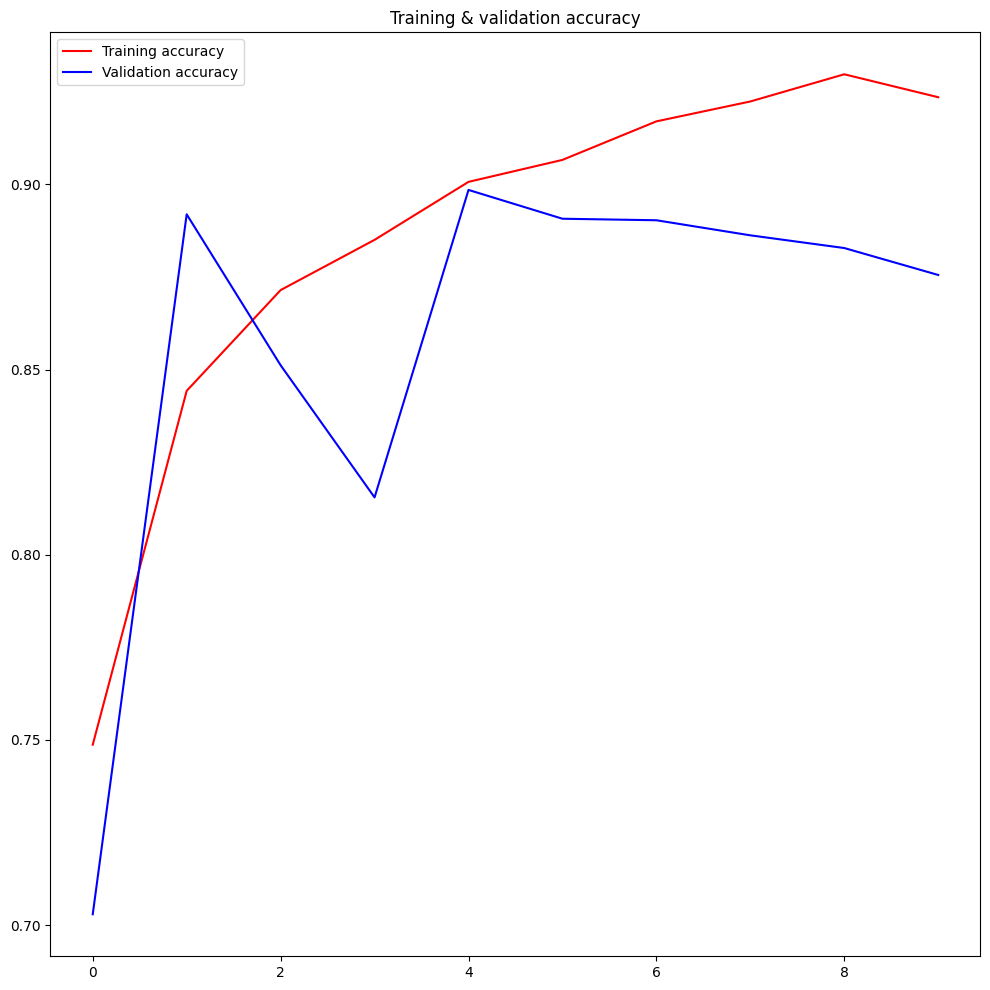

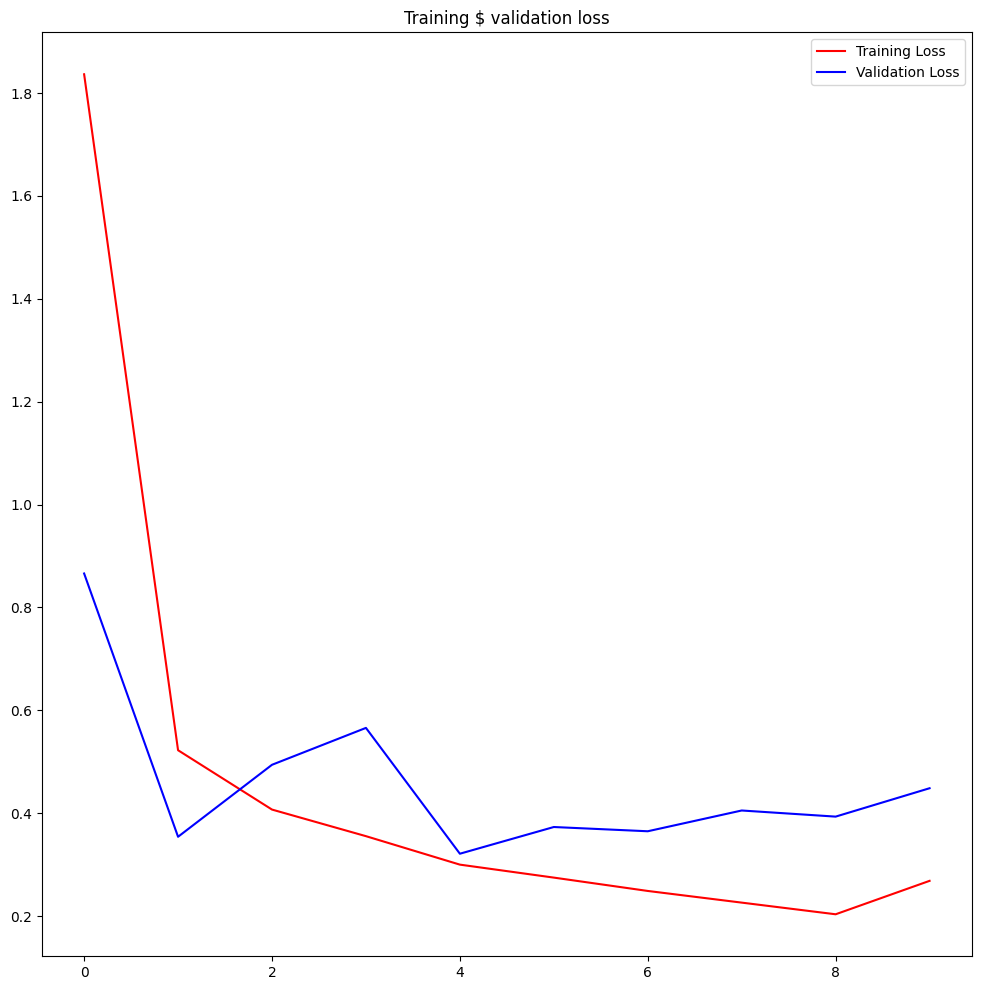

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12,12))

plt.plot(epochs, acc, 'r', label = 'Training accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation accuracy')
plt.title('Training & validation accuracy')
plt.legend()

plt.figure(figsize = (12,12))

plt.plot(epochs, loss, 'r', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training $ validation loss')
plt.legend()

In [22]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size = (224,224), class_mode = 'categorical', shuffle=False, 
    batch_size = 64)

Found 10933 images belonging to 4 classes.


In [23]:
model.evaluate(test_generator)

171/171 [==============================] - 27s 154ms/step - loss: 0.3250 - accuracy: 0.8967 - auc: 0.9819 - precision: 0.9014 - recall: 0.8920


[0.3249700367450714,
 0.8967346549034119,
 0.9819313883781433,
 0.9013772010803223,
 0.8919784426689148]

In [24]:
test_steps_per_epoch = np.math.ceil(test_generator.samples / test_generator.batch_size)

predictions = model.predict(test_generator, steps = test_steps_per_epoch)

predicted_classes = np.argmax(predictions, axis=1)

C:\Users\Aryan\AppData\Local\Temp\ipykernel_34160\1371022420.py:1: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  test_steps_per_epoch = np.math.ceil(test_generator.samples / test_generator.batch_size)


171/171 [==============================] - 27s 153ms/step


In [25]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())


In [26]:
report = sklearn.metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report) 

              precision    recall  f1-score   support

         CNV       0.93      0.92      0.93      3746
         DME       0.81      0.82      0.82      1161
      DRUSEN       0.59      0.65      0.62       887
      NORMAL       0.95      0.94      0.94      5139

    accuracy                           0.90     10933
   macro avg       0.82      0.83      0.83     10933
weighted avg       0.90      0.90      0.90     10933



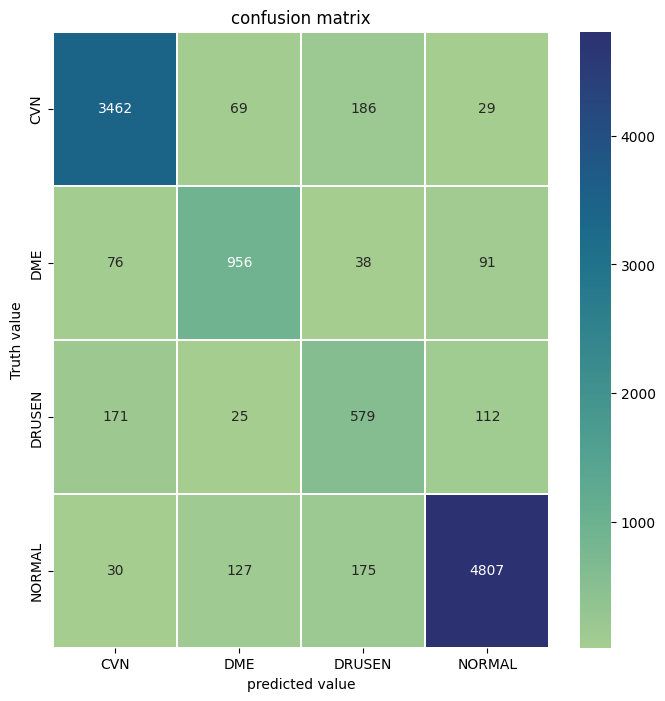

[[3462   69  186   29]
 [  76  956   38   91]
 [ 171   25  579  112]
 [  30  127  175 4807]]


In [27]:
X_Label = ['CVN','DME','DRUSEN','NORMAL']
Y_Label = ['CVN','DME','DRUSEN','NORMAL']

cm = sklearn.metrics.confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,8))
sns.heatmap(cm, fmt='.0f', cmap="crest", annot=True, linewidths=0.2, xticklabels=X_Label, yticklabels=Y_Label)
plt.title('confusion matrix')
plt.xlabel('predicted value')
plt.ylabel('Truth value')
plt.show()
print(sklearn.metrics.confusion_matrix(true_classes, predicted_classes))